# TUGAS ANALISIS DATA
Oleh: AGUSMA WAJIANSYAH (257150100011010)

Exploratory Data Analysis (EDA) untuk data gambar (image) menggunakan Python. EDA pada citra bertujuan memahami karakteristik dataset seperti dimensi, tipe warna, distribusi intensitas piksel, kualitas, anomali, dan variasi antar kelas.

Sumber Data: Labelled Faces in the Wild (LFW) Dataset (https://www.kaggle.com/datasets/jessicali9530/lfw-dataset)

pada percobaan ini, hanya menggunakan 212 class dari 5749 class yang ada pada datasheet yang dipilih secara acak, agar dapat dijalankan pada google colab.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **1. Persiapan & Library**

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from glob import glob
from collections import Counter
import pandas as pd

# **2. Memuat Informasi Dasar Dataset**
**a. Struktur direktori & jumlah sampel**

     Untuk melihat struktur dan statistik dasar dari dataset gambar wajah

In [5]:
train_path = "/content/drive/MyDrive/Colab Notebooks/lfw-deepfunneled212/"
classes = os.listdir(train_path)
print("Jumlah kelas:", len(classes))
print("Nama kelas:", classes)

# Hitung jumlah gambar per kelas
class_counts = {cls: len(glob(os.path.join(train_path, cls, "*"))) for cls in classes}
print(class_counts)

Jumlah kelas: 212
Nama kelas: ['Amber_Tamblyn', 'Amelia_Vega', 'Barbra_Streisand', 'Amer_al-Saadi', 'Barry_Alvarez', 'Andrea_Bocelli', 'Aaron_Sorkin', 'Bart_Hendricks', 'Andy_Lau', 'Andrew_Bernard', 'Beecher_Ray_Kirby', 'Amelie_Mauresmo', 'Andre_Agassi', 'Amy_Cotton', 'Amy_Yasbeck', 'Bartosz_Kizierowski', 'Barbara_Bodine', 'Barzan_al-Tikriti', 'Begum_Khaleda_Zia', 'Bixente_LIzarazu', 'Casey_Mears', 'BJ_Habibie', 'Bryan_Adams', 'Cathryn_Crawford', 'Cassandra_Heise', 'Choi_Sung-hong', 'Bode_Miller', 'Carson_Palmer', 'Carol_Burnett', 'Cabas', 'Dai_Bachtiar', 'Dean_Sheremet', 'Dagmar_Dunlevy', 'Debbie_Reynolds', 'Dean_Jacek', 'David_Beckham', 'Craig_MacTavish', 'Debra_Brown', 'Christopher_Speer', 'Dale_Earnhardt', 'Doug_Collins', 'Demi_Moore', 'Dita_Von_Tesse', 'Eliane_Karp', 'Dwayne_Wade', 'Djabir_Said-Guerni', 'Delphine_Chuillot', 'Elena_Bovina', 'Din_Samsudin', 'Demetrin_Veal', 'Elin_Nordegren', 'Eliza_Manningham-Buller', 'Elijah_Wood', 'Eli_Rosenbaum', 'Eminem', 'Elizabeth_Dole', 'Elvi

**b. Ekstrak metadata ke DataFrame**

    membuat sebuah tabel (DataFrame) yang berisi informasi lengkap tentang setiap gambar di dalam dataset

In [7]:
data = []
for cls in classes:
    for img_path in glob(os.path.join(train_path, cls, "*")):
        img = Image.open(img_path)
        w, h = img.size
        mode = img.mode  # 'RGB', 'L', 'RGBA', dll.
        data.append([img_path, cls, w, h, mode])

df = pd.DataFrame(data, columns=["path", "class", "width", "height", "mode"])
print(df.head(5))   # 5 baris pertama
print(df.tail(5))   # 5 baris terakhir

                                                path          class  width  \
0  /content/drive/MyDrive/Colab Notebooks/lfw-dee...  Amber_Tamblyn    250   
1  /content/drive/MyDrive/Colab Notebooks/lfw-dee...  Amber_Tamblyn    250   
2  /content/drive/MyDrive/Colab Notebooks/lfw-dee...    Amelia_Vega    250   
3  /content/drive/MyDrive/Colab Notebooks/lfw-dee...    Amelia_Vega    250   
4  /content/drive/MyDrive/Colab Notebooks/lfw-dee...    Amelia_Vega    250   

   height mode  
0     250  RGB  
1     250  RGB  
2     250  RGB  
3     250  RGB  
4     250  RGB  
                                                  path            class  \
861  /content/drive/MyDrive/Colab Notebooks/lfw-dee...  Zinedine_Zidane   
862  /content/drive/MyDrive/Colab Notebooks/lfw-dee...  Zinedine_Zidane   
863  /content/drive/MyDrive/Colab Notebooks/lfw-dee...  Zinedine_Zidane   
864  /content/drive/MyDrive/Colab Notebooks/lfw-dee...  Zinedine_Zidane   
865  /content/drive/MyDrive/Colab Notebooks/lfw-dee...

# **3. Analisis Dimensi & Aspek Rasio**

       width  height
count  866.0   866.0
mean   250.0   250.0
std      0.0     0.0
min    250.0   250.0
25%    250.0   250.0
50%    250.0   250.0
75%    250.0   250.0
max    250.0   250.0


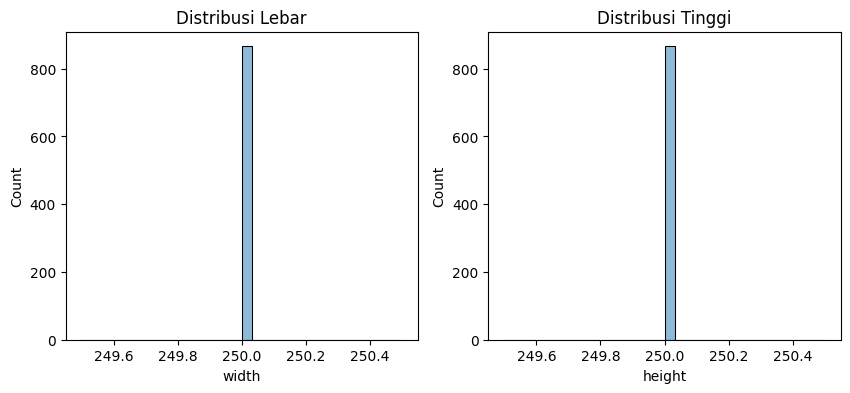

Jumlah variasi ukuran: 1


In [8]:
# Distribusi ukuran gambar
print(df[['width','height']].describe())

# Plot ukuran
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['width'], bins=30, kde=True)
plt.title('Distribusi Lebar')
plt.subplot(1,2,2)
sns.histplot(df['height'], bins=30, kde=True)
plt.title('Distribusi Tinggi')
plt.show()

# Cek apakah semua gambar memiliki ukuran yang sama
ukuran_unik = df.groupby(['width','height']).size()
print("Jumlah variasi ukuran:", len(ukuran_unik))

# **4. Mode Warna & Kedalaman Bit**

menganalisis dan memvisualisasikan mode warna dari semua gambar dalam dataset, serta menghitung jumlah channel warna setiap gambar.

Memeriksa apakah semua gambar memiliki format warna yang konsisten atau bervariasi

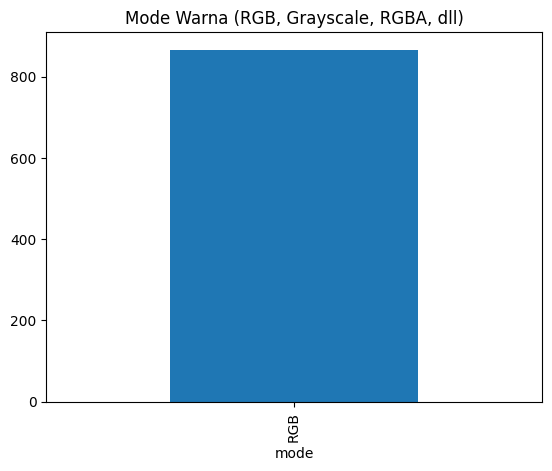

In [6]:
# Distribusi mode warna
df['mode'].value_counts().plot(kind='bar')
plt.title('Mode Warna (RGB, Grayscale, RGBA, dll)')
plt.show()

# Cek jumlah channel
df['channels'] = df['mode'].apply(lambda m: 3 if m=='RGB' else (1 if m=='L' else 4))

# **5. Visualisasi Sampel Gambar**

**a. Grid per kelas**

menampilkan grid gambar sampel dari setiap kelas (orang) dalam dataset, dengan 4 gambar per orang. Visualisasi sampel wajah dari setiap orang di dataset LFW untuk inspeksi visual

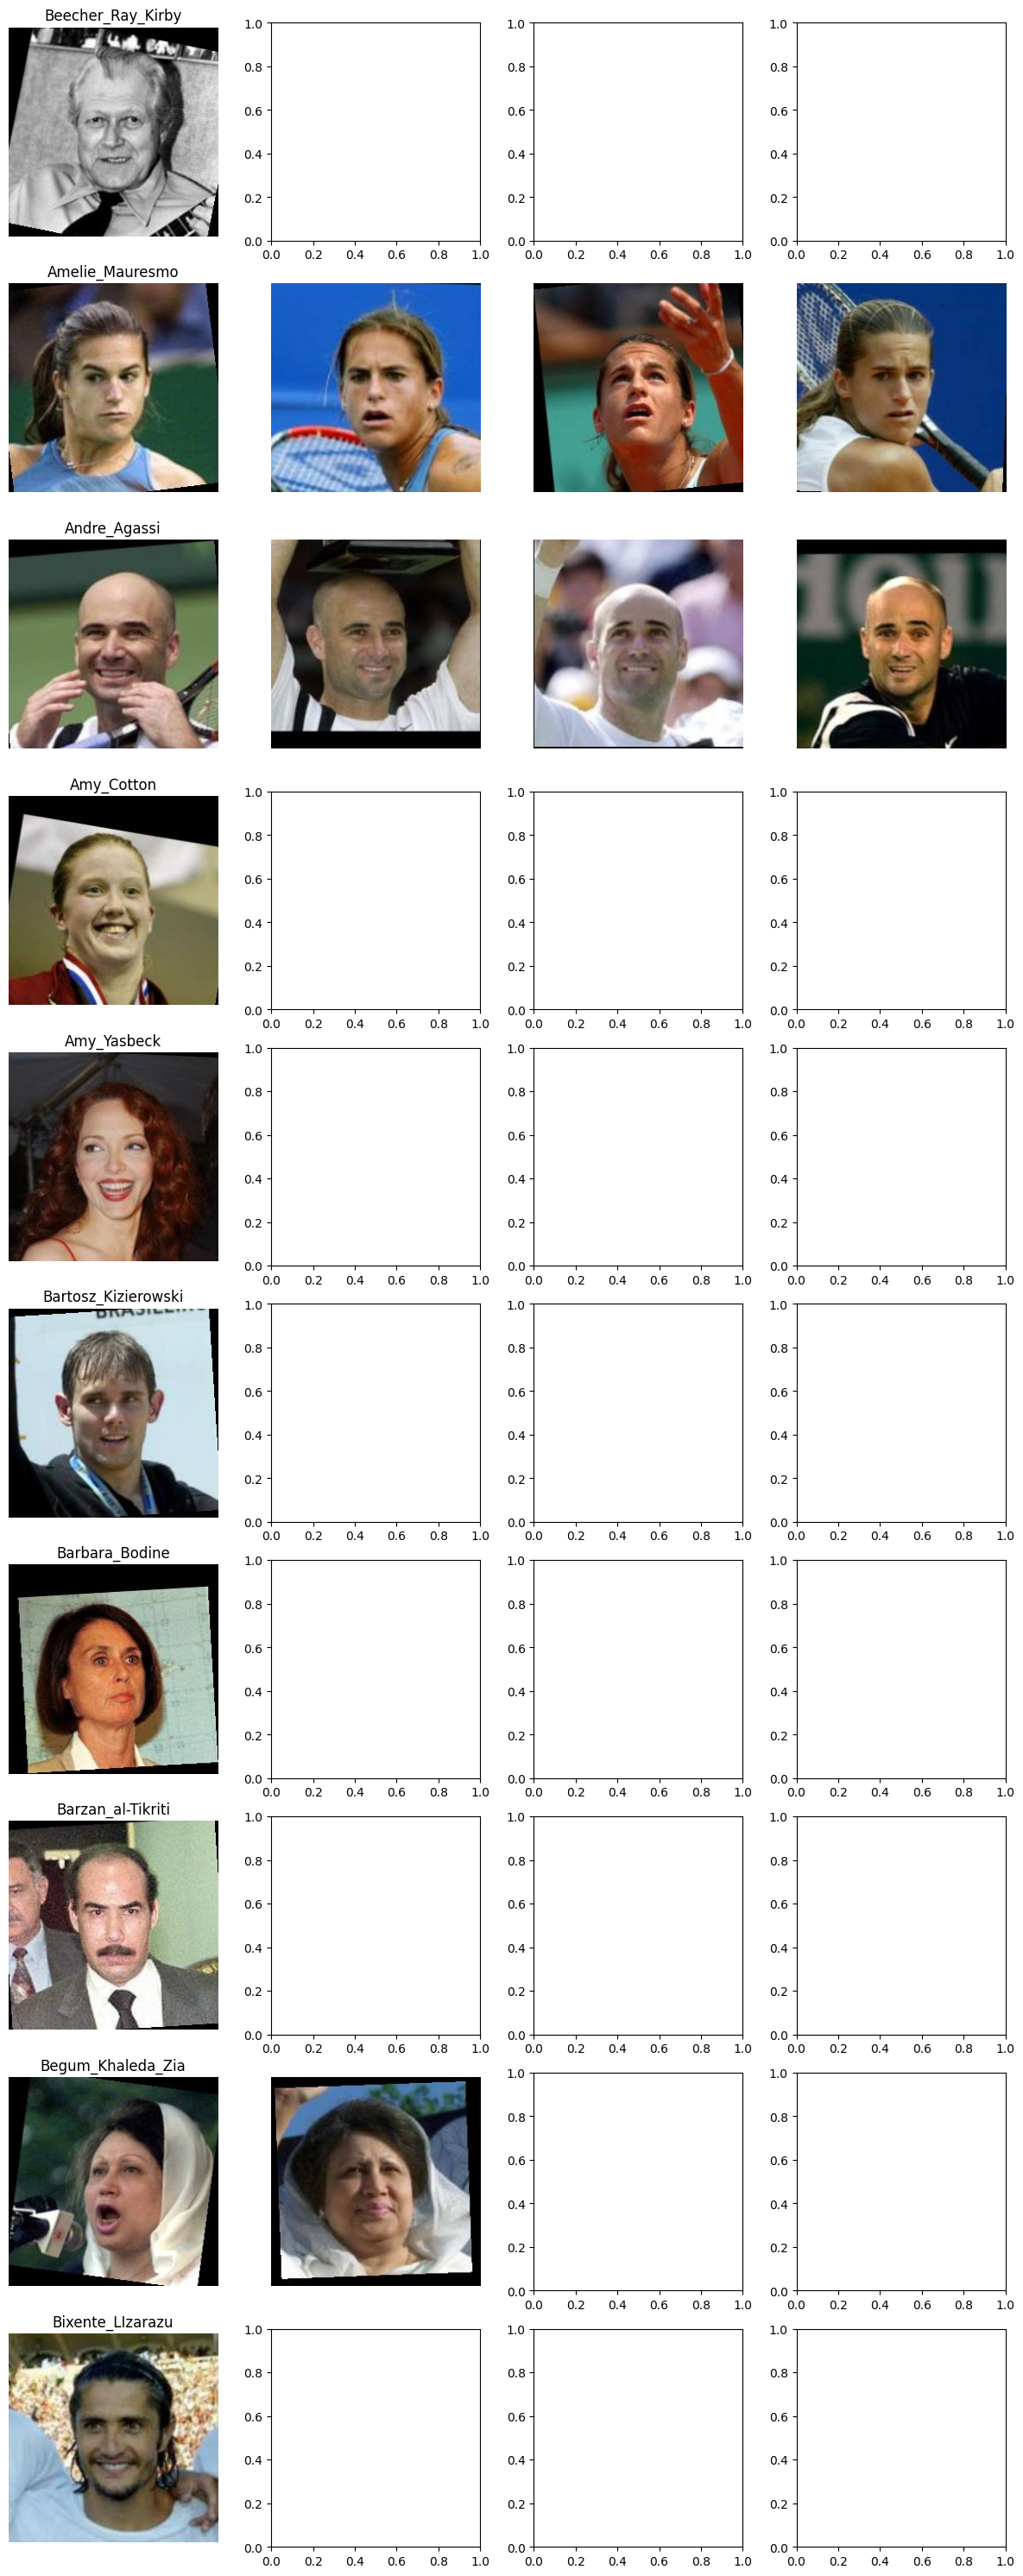

In [10]:
#selected_classes = classes[:10] # Tampilkan 10 orang pertama saja
selected_classes = classes[10:20] # Tampilkan 11 hingga orang ke-20 saja
fig, axes = plt.subplots(len(selected_classes), 4, figsize=(12, 3*len(selected_classes)))
for i, cls in enumerate(selected_classes):
    images = glob(os.path.join(train_path, cls, "*"))[:4]
    for j, img_path in enumerate(images):
        img = plt.imread(img_path)
        axes[i,j].imshow(img)
        axes[i,j].axis('off')
        axes[i,j].set_title(cls if j==0 else "")
plt.tight_layout()
plt.show()

**b. Plot gambar dengan ukuran & mode warna anomali**

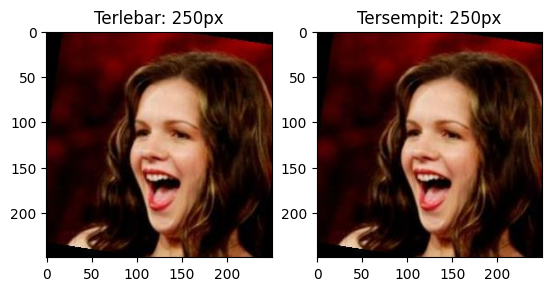

In [11]:
# Cari gambar dengan ukuran paling ekstrem
max_width = df[df['width'] == df['width'].max()]['path'].values[0]
min_width = df[df['width'] == df['width'].min()]['path'].values[0]

img_max = plt.imread(max_width)
img_min = plt.imread(min_width)
plt.subplot(1,2,1); plt.imshow(img_max); plt.title(f"Terlebar: {df['width'].max()}px")
plt.subplot(1,2,2); plt.imshow(img_min); plt.title(f"Tersempit: {df['width'].min()}px")
plt.show()

Statistik Lebar:
  Rata-rata: 250.0px
  Median: 250.0px
  Terlebar: 250px
  Tersempit: 250px
  Standar deviasi: 0.0px

Rasio aspek ekstrim:
  Paling lebar: 1.00
  Paling tinggi: 1.00


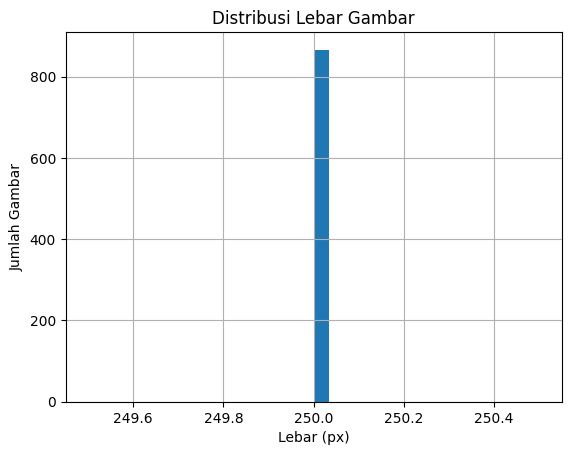

In [12]:
# 1. Cek juga untuk tinggi (height)
max_height = df[df['height'] == df['height'].max()]['path'].values[0]
min_height = df[df['height'] == df['height'].min()]['path'].values[0]

# 2. Statistik lengkap dimensi
print("Statistik Lebar:")
print(f"  Rata-rata: {df['width'].mean():.1f}px")
print(f"  Median: {df['width'].median():.1f}px")
print(f"  Terlebar: {df['width'].max()}px")
print(f"  Tersempit: {df['width'].min()}px")
print(f"  Standar deviasi: {df['width'].std():.1f}px")

# 3. Cek apakah ada gambar yang tidak proporsional
df['aspect_ratio'] = df['width'] / df['height']
print(f"\nRasio aspek ekstrim:")
print(f"  Paling lebar: {df['aspect_ratio'].max():.2f}")
print(f"  Paling tinggi: {df['aspect_ratio'].min():.2f}")

# 4. Tampilkan distribusi lebar
df['width'].hist(bins=30)
plt.title('Distribusi Lebar Gambar')
plt.xlabel('Lebar (px)')
plt.ylabel('Jumlah Gambar')
plt.show()

# **6. Analisis Statistik Intensitas Piksel**

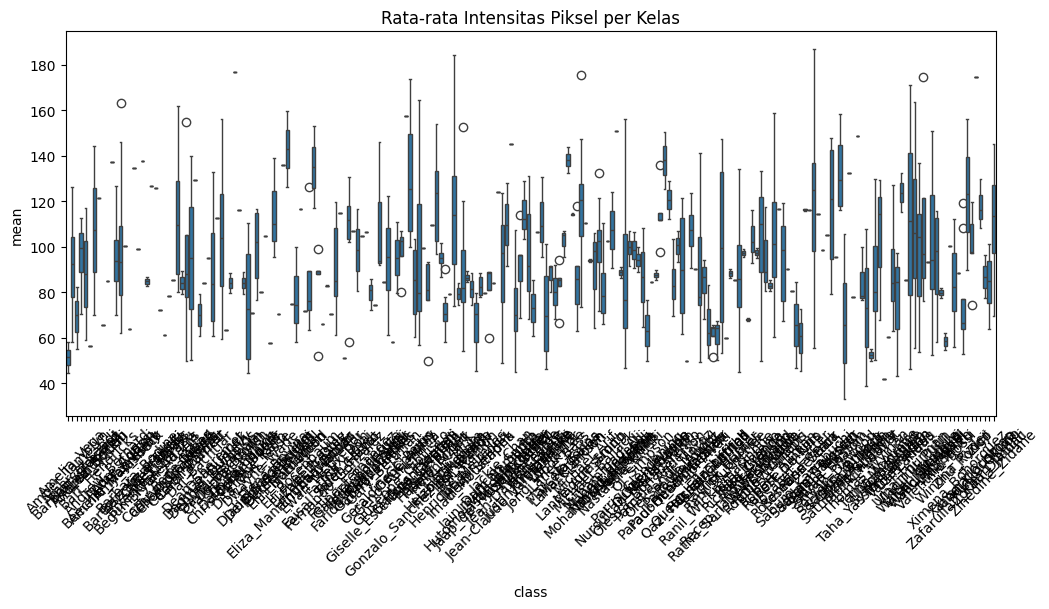

In [9]:
def pixel_stats(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return {
        'mean': np.mean(img_rgb),
        'std': np.std(img_rgb),
        'min': np.min(img_rgb),
        'max': np.max(img_rgb)
    }

stats = df['path'].apply(pixel_stats)
df_stats = pd.DataFrame(stats.tolist())
df = pd.concat([df, df_stats], axis=1)

# Distribusi mean intensitas per kelas
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='class', y='mean')
plt.title('Rata-rata Intensitas Piksel per Kelas')
plt.xticks(rotation=45)
plt.show()

# **7. Histogram Warna per Channel**

membuat histogram distribusi warna RGB dari satu gambar sampel per kelas dalam dataset.

Tujuan menganalisis dan membandingkan distribusi warna (RGB) dari setiap orang di dataset

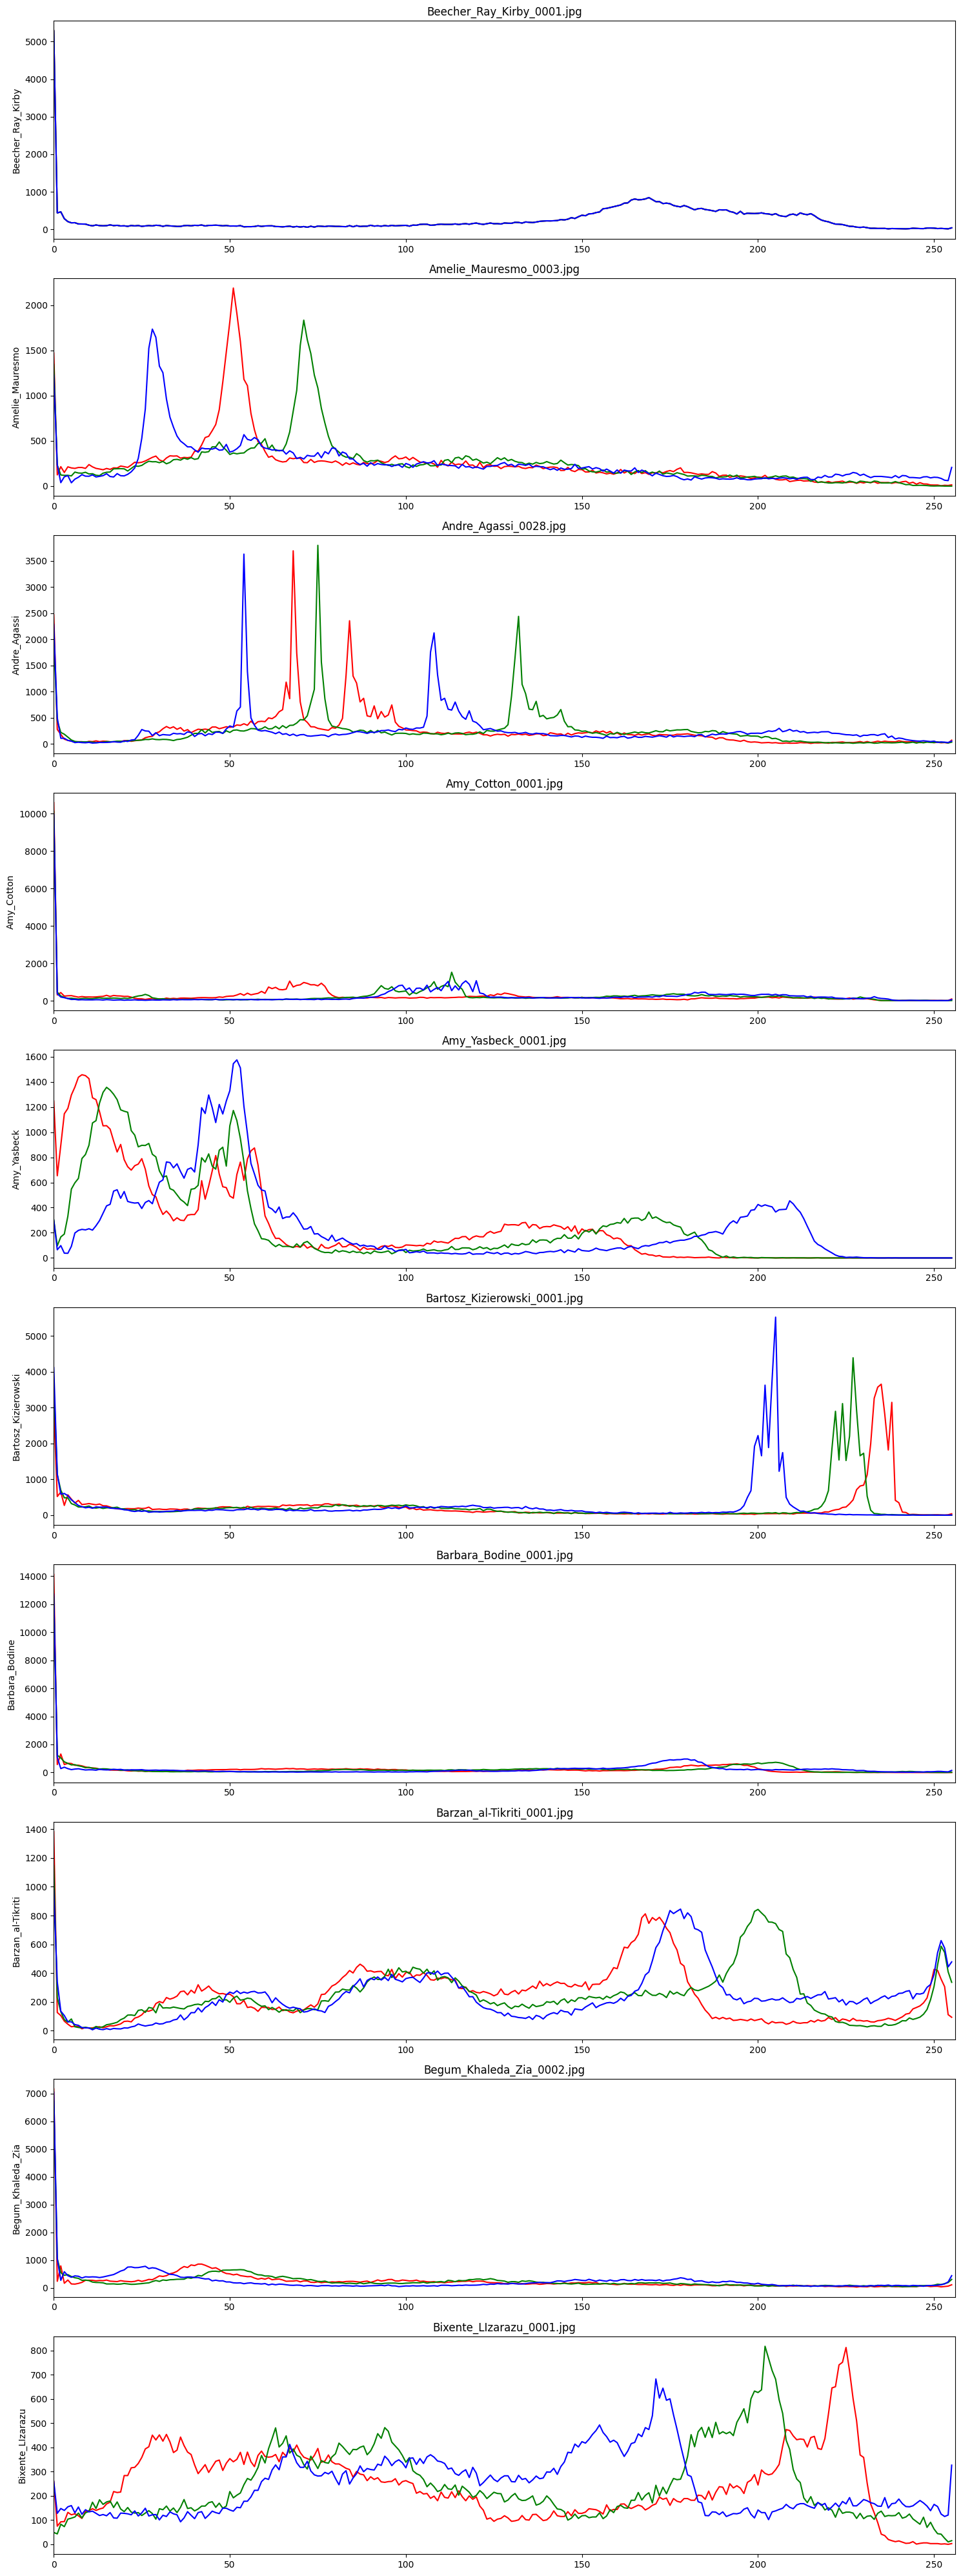

In [13]:
def plot_histogram_rgb(img_path):
    img = cv2.imread(img_path)
    colors = ('r','g','b')
    for i, color in enumerate(colors):
        hist = cv2.calcHist([img], [i], None, [256], [0,256])
        plt.plot(hist, color=color)
    plt.title(os.path.basename(img_path))
    plt.xlim([0,256])

# Menampilkan data histrogram pada class yang ditentukan
plt.figure(figsize=(15, 4*len(selected_classes)))
for i, cls in enumerate(selected_classes):
    sample = glob(os.path.join(train_path, cls, "*"))[0]
    plt.subplot(len(selected_classes), 1, i+1)
    plot_histogram_rgb(sample)
    plt.ylabel(cls)
plt.tight_layout()
plt.show()

# **8. Deteksi Anomali (Gambar Rusak, Duplikat, Noise)**

**a. Cek file corrupt**

In [11]:
corrupt = []
for img_path in df['path']:
    try:
        img = Image.open(img_path)
        img.verify()
    except:
        corrupt.append(img_path)
print("Gambar corrupt:", corrupt)

Gambar corrupt: []


**b. Deteksi duplikat (hash sederhana)**

In [12]:
import hashlib
hashes = {}
duplicates = []
for img_path in df['path']:
    with open(img_path, 'rb') as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
    if file_hash in hashes:
        duplicates.append((img_path, hashes[file_hash]))
    else:
        hashes[file_hash] = img_path
print("Duplikat:", duplicates)

Duplikat: []


**c. Cek gambar seragam (misal semua piksel hitam/putih)**

In [13]:
uniform = []
for idx, row in df.iterrows():
    if row['std'] == 0:
        uniform.append(row['path'])
print("Gambar uniform (std=0):", uniform)

Gambar uniform (std=0): []


# **9. Visualisasi dengan T-SNE atau PCA (untuk feature extraction)**

Jika gambar sudah diubah menjadi vektor fitur (misal dengan pretrained CNN):

/tmp/ipykernel_21448/994246771.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


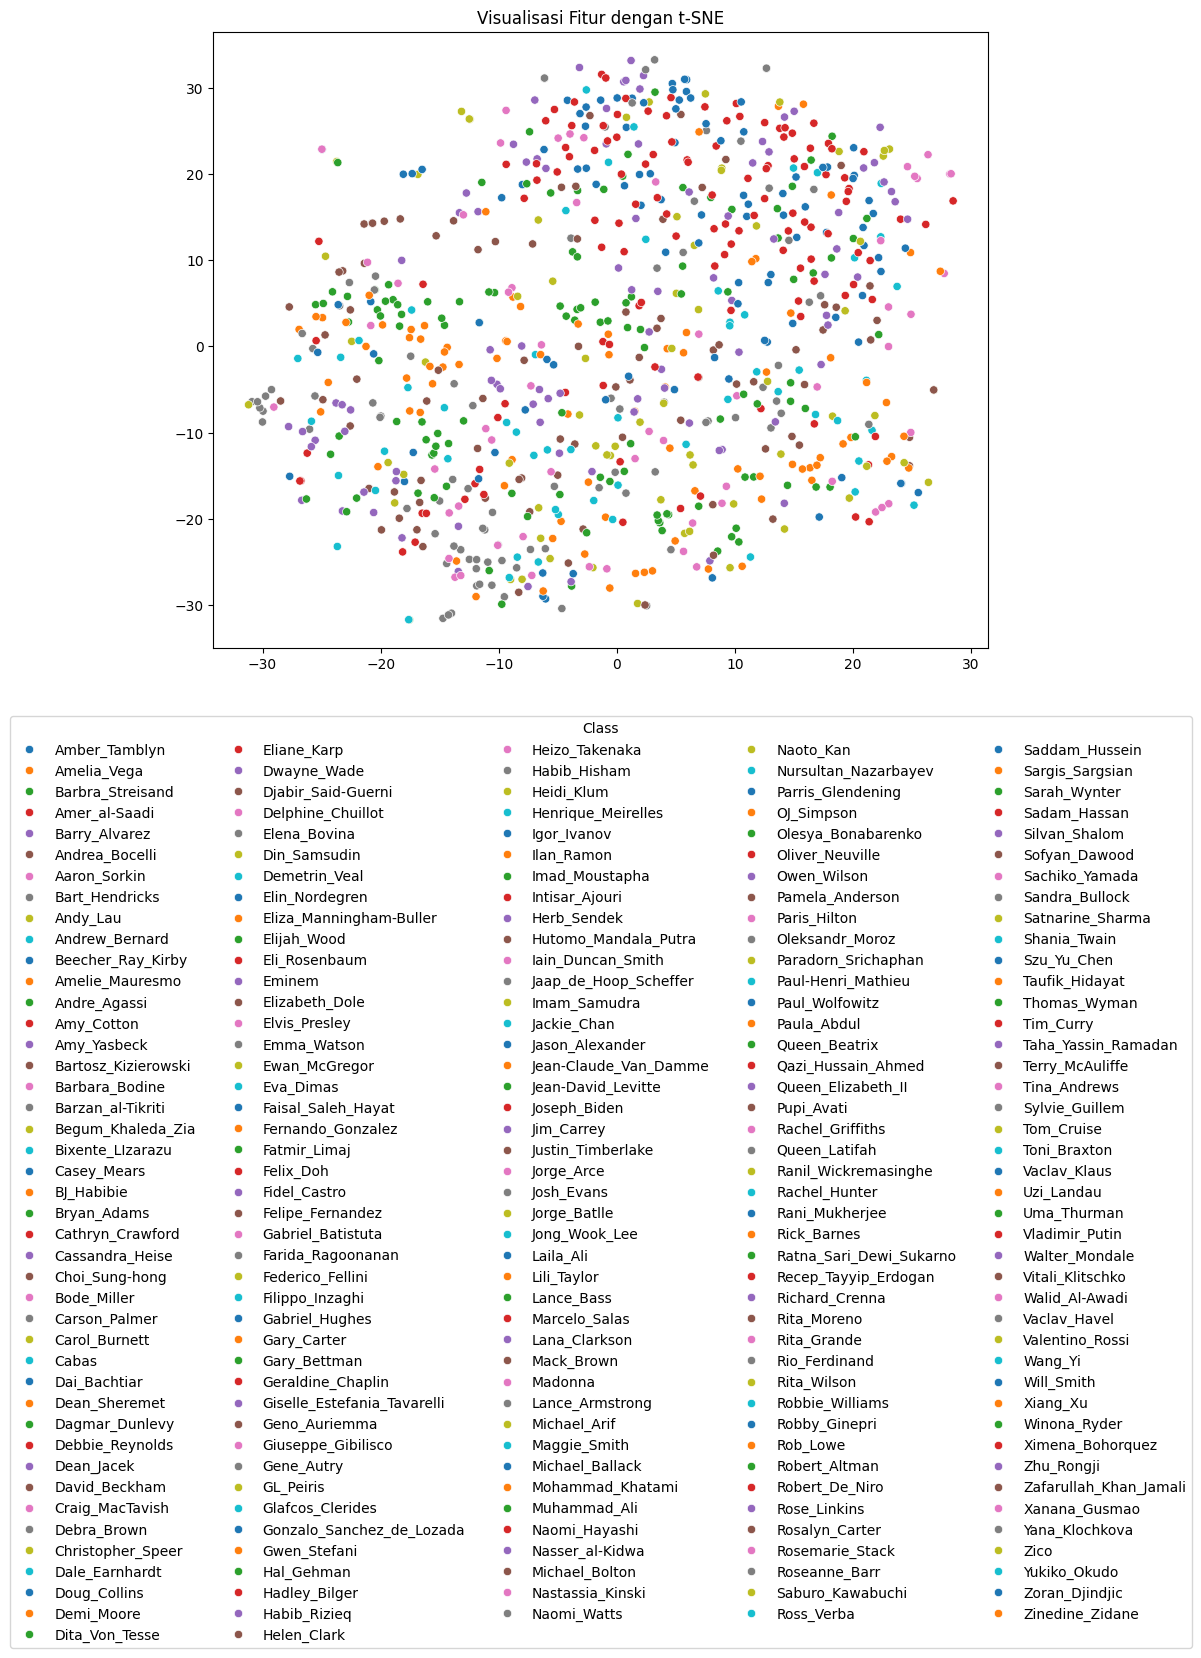

In [15]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Ekstrak fitur dengan ResNet50 (tanpa top layer)
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def extract_features(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    x = tf.keras.preprocessing.image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x, verbose=0)
    return features.flatten()

features = np.array([extract_features(p) for p in df['path']])
# PCA + t-SNE
pca = PCA(n_components=50)
pca_result = pca.fit_transform(features)
tsne = TSNE(n_components=2, perplexity=30)
tsne_result = tsne.fit_transform(pca_result)

plt.figure(figsize=(10,8))
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=df['class'], palette='tab10')
plt.title('Visualisasi Fitur dengan t-SNE')
plt.legend(title='Class', bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=5)
plt.tight_layout()
plt.show()